# Summative Lab: Machine Learning Model for Loan Approval

## Overview (BLUF)
This notebook follows CRISP-DM to build and evaluate a loan approval model for FinTech Innovations.
The solution prioritizes business impact with asymmetric error costs: false approvals = $50,000 and false denials = $8,000.

## 1) Business Understanding

### Stakeholders
- Loan officers: consistent recommendations
- Risk team: fewer costly bad approvals
- Leadership: better profitability and throughput
- Applicants: fair and faster decisions

### Modeling choice
We use **classification** on `LoanApproved` and evaluate with both statistical and business-cost metrics.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, pointbiserialr

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

In [11]:
paths = [
    r'c:\\Users\\ayu9s\\Downloads\\financial_loan_data.csv',
    r'./financial_loan_data.csv',
    r'c:\\Users\\ayu9s\\Downloads\\archive (3)\\Loan.csv'
]
path = next((p for p in paths if pd.io.common.file_exists(p)), None)
if path is None:
    raise FileNotFoundError('Dataset not found in expected paths.')

df = pd.read_csv(path)

categorical_hints = {
    'ApplicationDate', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus',
    'HomeOwnershipStatus', 'LoanPurpose'
}
for col in df.columns:
    if col in categorical_hints:
        continue
    if pd.api.types.is_string_dtype(df[col]):
        cleaned = df[col].astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
        converted = pd.to_numeric(cleaned, errors='coerce')
        if converted.notna().mean() >= 0.9:
            df[col] = converted

if 'LoanApproved' in df.columns:
    df['LoanApproved'] = pd.to_numeric(df['LoanApproved'], errors='coerce').fillna(0).astype(int)

print('Loaded:', path)
print('Shape:', df.shape)
print('Object columns after cleaning:', df.select_dtypes(include=['object', 'str']).columns.tolist())
display(df.head())

Loaded: c:\\Users\\ayu9s\\Downloads\\financial_loan_data.csv
Shape: (20000, 35)
Object columns after cleaning: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,39948.0,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,39709.0,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,40724.0,570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,69084.0,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,103264.0,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


## 2) Data Understanding

In [12]:
target_col = 'LoanApproved'

print(df.dtypes.value_counts())
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame('missing_count'))
print('Duplicate rows:', int(df.duplicated().sum()))
display(df[target_col].value_counts(normalize=True).rename('proportion'))

int64      18
float64    11
str         6
Name: count, dtype: int64


,missing_count
MaritalStatus,1331
EducationLevel,901
SavingsAccountBalance,572


Duplicate rows: 0


LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64

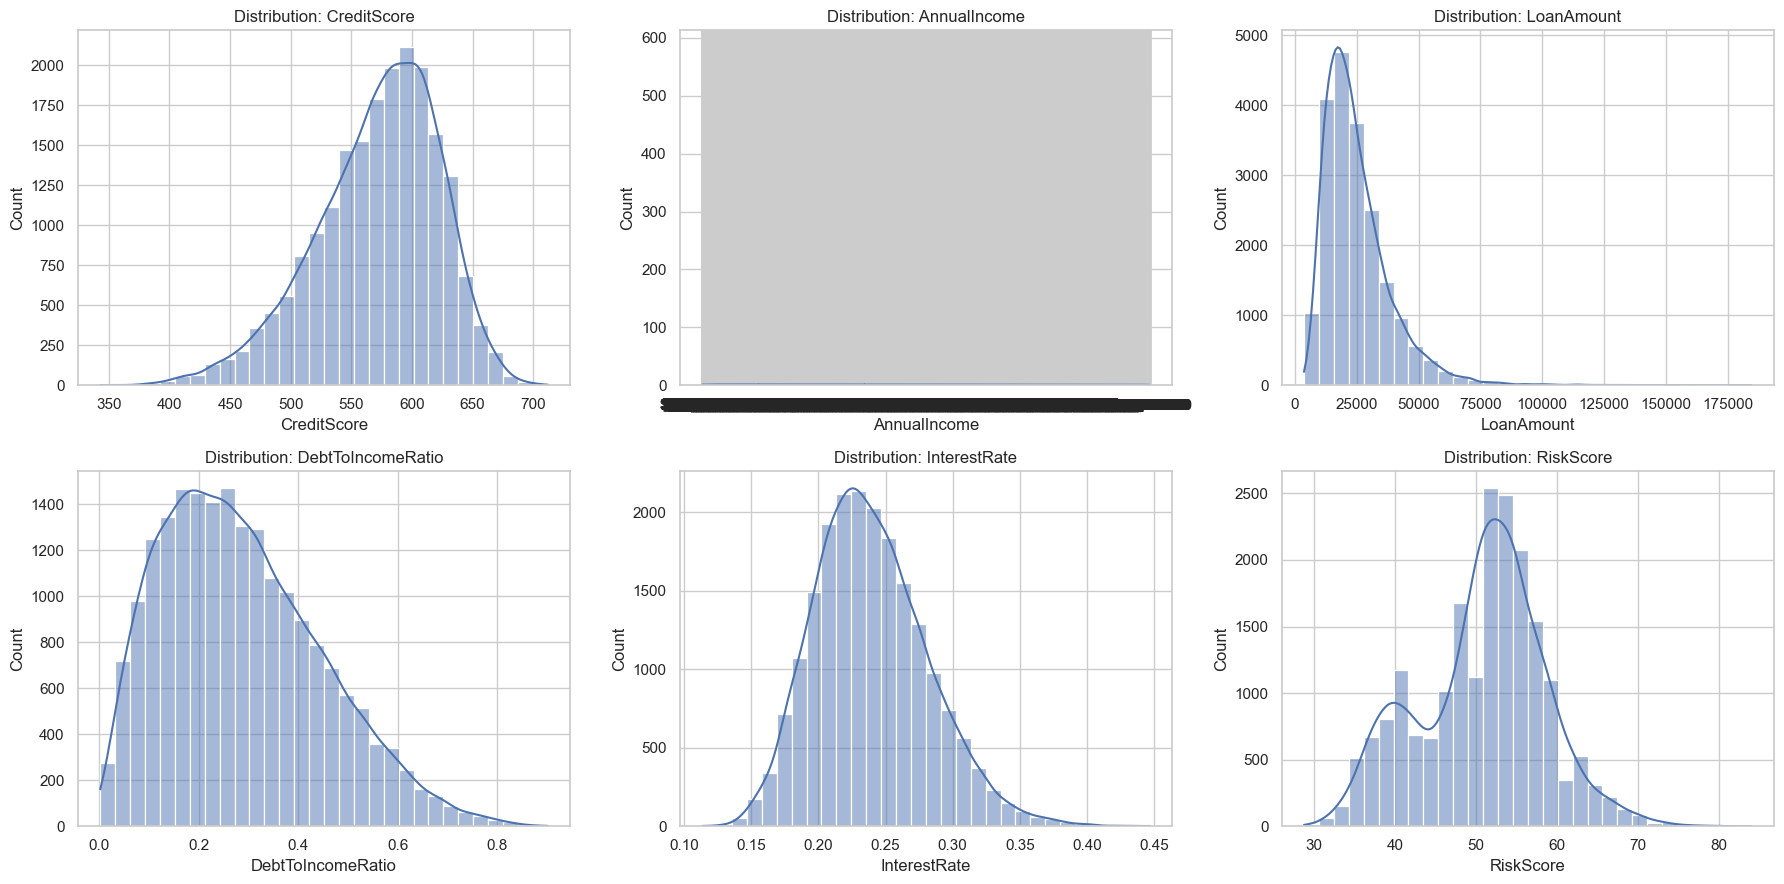

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
plot_cols = ['CreditScore', 'AnnualIncome', 'LoanAmount', 'DebtToIncomeRatio', 'InterestRate', 'RiskScore']
for ax, col in zip(axes.flatten(), plot_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=ax)
    ax.set_title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

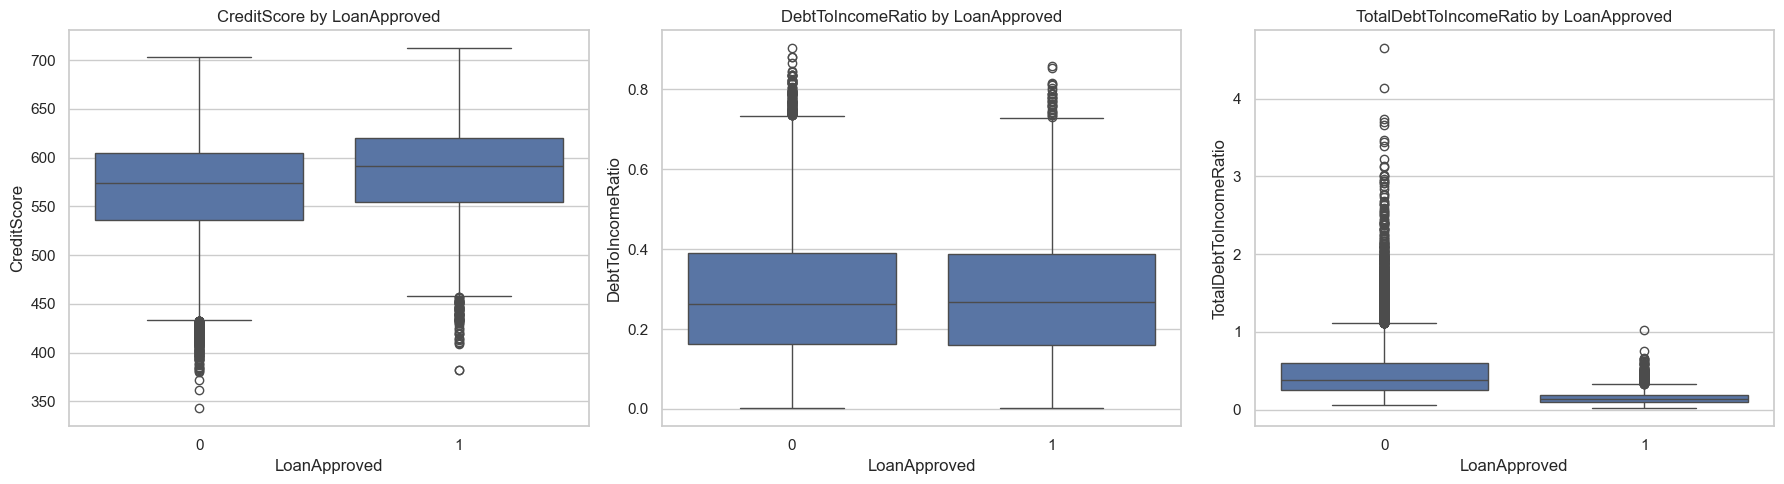

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['CreditScore', 'DebtToIncomeRatio', 'TotalDebtToIncomeRatio']):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f'{col} by LoanApproved')
plt.tight_layout()
plt.show()

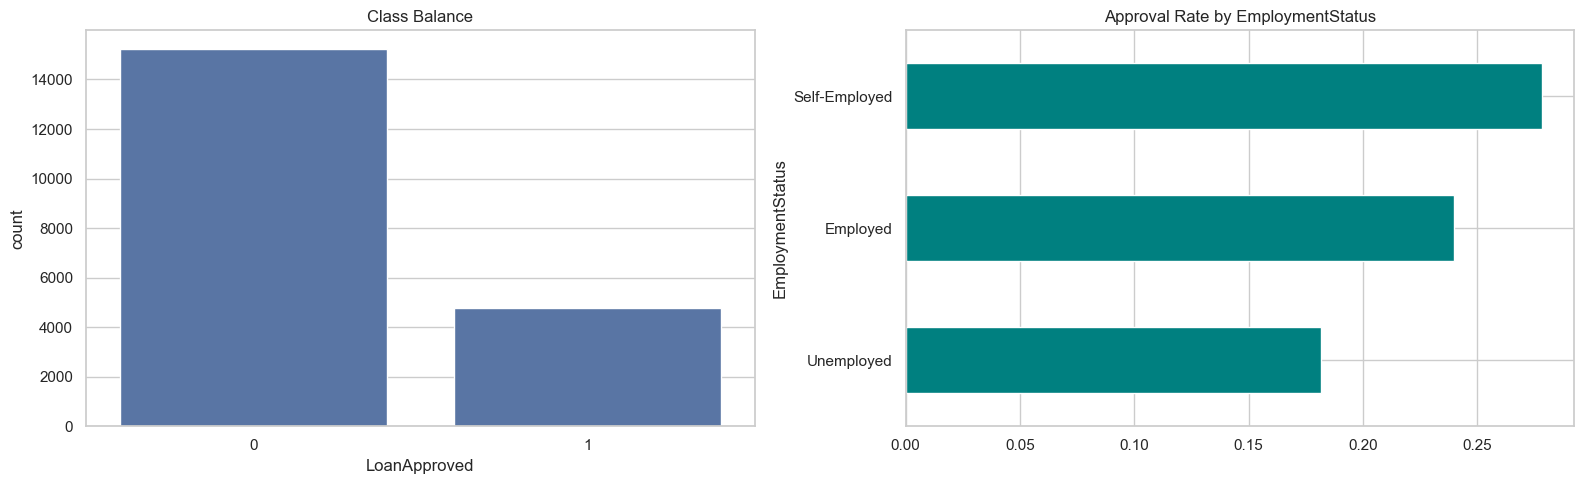

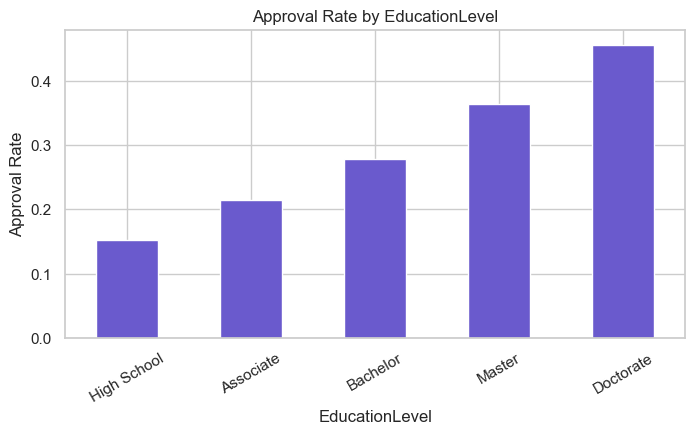

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df, x=target_col, ax=axes[0])
axes[0].set_title('Class Balance')

emp_rate = pd.crosstab(df['EmploymentStatus'], df[target_col], normalize='index')
emp_rate[1].sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Approval Rate by EmploymentStatus')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
edu_rate = pd.crosstab(df['EducationLevel'], df[target_col], normalize='index')
edu_rate[1].sort_values().plot(kind='bar', color='slateblue')
plt.title('Approval Rate by EducationLevel')
plt.ylabel('Approval Rate')
plt.xticks(rotation=30)
plt.show()

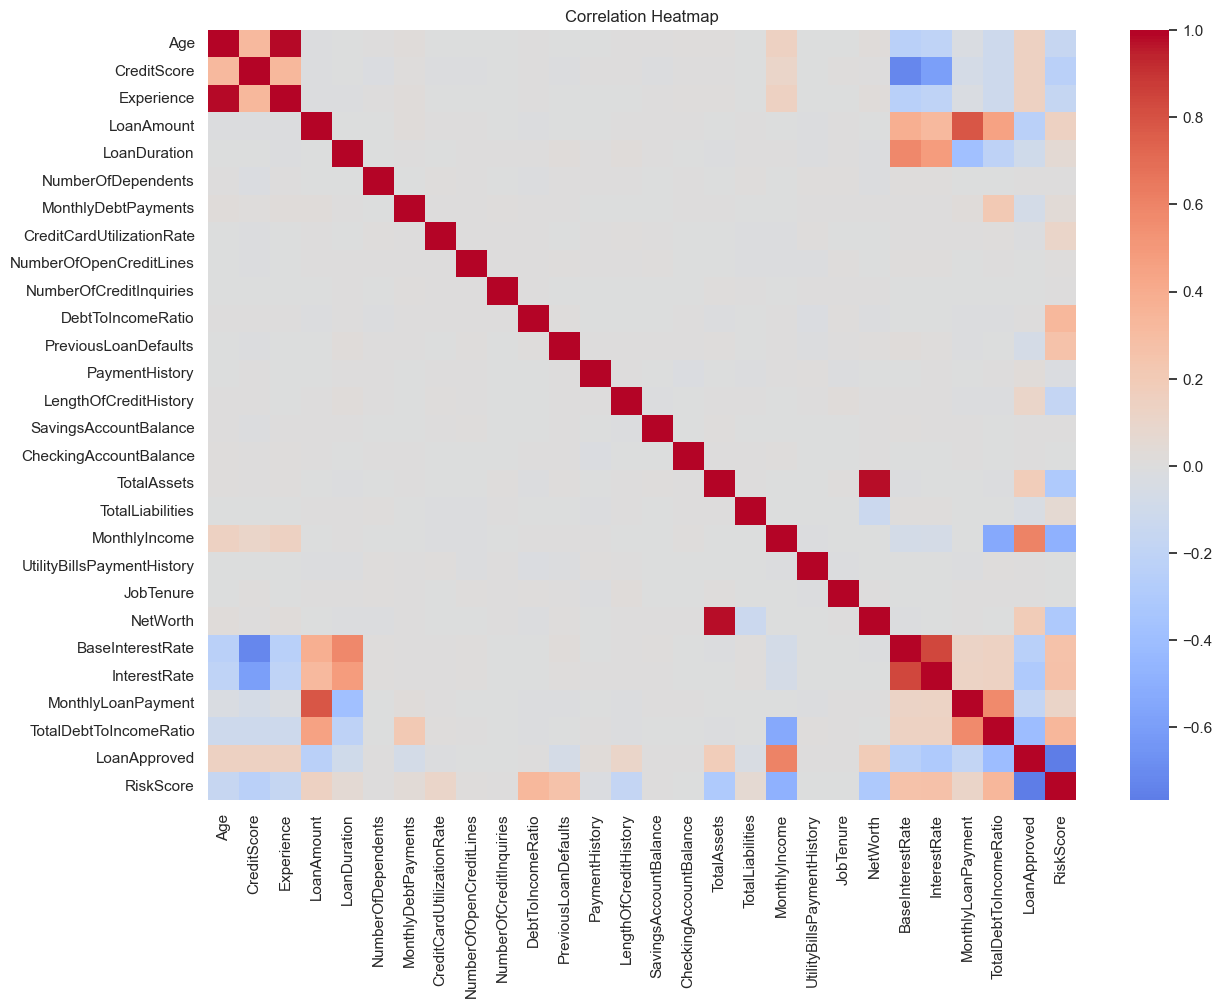

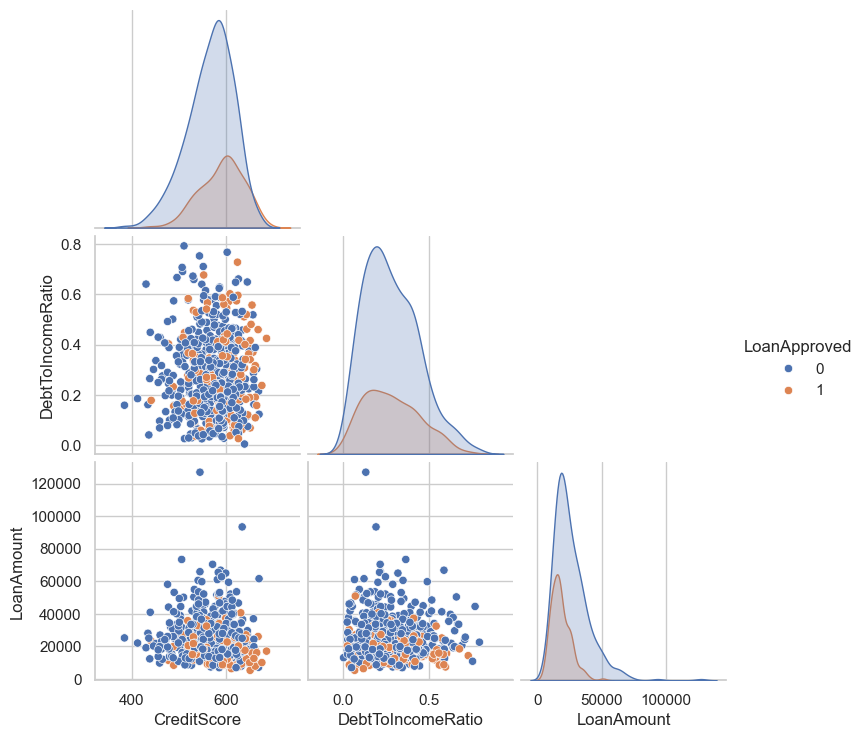

In [7]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

pp_cols = ['CreditScore', 'DebtToIncomeRatio', 'AnnualIncome', 'LoanAmount', target_col]
pp_sample = df[pp_cols].dropna().sample(min(600, len(df)), random_state=42)
sns.pairplot(pp_sample, hue=target_col, diag_kind='kde', corner=True)
plt.show()

In [13]:
for col in ['CreditScore', 'DebtToIncomeRatio', 'AnnualIncome', 'RiskScore']:
    valid = df[[col, target_col]].copy()
    valid[col] = pd.to_numeric(valid[col], errors='coerce')
    valid[target_col] = pd.to_numeric(valid[target_col], errors='coerce')
    valid = valid.dropna()
    r, p = pointbiserialr(valid[target_col], valid[col])
    print(f'{col:22s} r={r: .3f}, p={p:.3e}')

for col in ['EmploymentStatus', 'EducationLevel', 'HomeOwnershipStatus']:
    valid = df[[col, target_col]].dropna()
    chi2, p, _, _ = chi2_contingency(pd.crosstab(valid[col], valid[target_col]))
    print(f'{col:22s} chi2={chi2: .2f}, p={p:.3e}')

CreditScore            r= 0.142, p=1.382e-90
DebtToIncomeRatio      r= 0.000, p=9.961e-01
AnnualIncome           r= 0.598, p=0.000e+00
RiskScore              r=-0.766, p=0.000e+00
EmploymentStatus       chi2= 38.51, p=4.349e-09
EducationLevel         chi2= 748.90, p=8.976e-161
HomeOwnershipStatus    chi2= 26.33, p=8.139e-06


## 3) Data Preparation
- Numeric: median imputation + scaling
- Categorical: most-frequent imputation + one-hot encoding
- Full preprocessing embedded in `ColumnTransformer` + `Pipeline`
- Leakage guardrail: `RiskScore` is excluded from model features because it behaves like a post-hoc/derived outcome proxy

In [14]:
leakage_features = ['RiskScore']
X = df.drop(columns=[target_col] + leakage_features, errors='ignore')
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_features = X_train.select_dtypes(include=['number']).columns.tolist()
cat_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

def build_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', build_ohe())
    ]), cat_features)
])

print('Excluded leakage-like features:', leakage_features)
print('Numeric:', len(num_features), 'Categorical:', len(cat_features))

Numeric: 28 Categorical: 6


## 4) Iterative Modeling
Model comparison uses 5-fold cross-validation and a custom business-cost scorer.

In [15]:
FN_COST = 8000
FP_COST = 50000

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp * FP_COST + fn * FN_COST

def business_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tp * FN_COST - fp * FP_COST

scoring = {
    'roc_auc': 'roc_auc',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'neg_business_cost': make_scorer(business_cost, greater_is_better=False),
    'business_value': make_scorer(business_value, greater_is_better=True)
}

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    out = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        'model': name,
        'cv_roc_auc': np.mean(out['test_roc_auc']),
        'cv_f1': np.mean(out['test_f1']),
        'cv_precision': np.mean(out['test_precision']),
        'cv_recall': np.mean(out['test_recall']),
        'cv_business_cost': -np.mean(out['test_neg_business_cost']),
        'cv_business_value': np.mean(out['test_business_value'])
    })

results_df = pd.DataFrame(rows).sort_values(['cv_business_cost', 'cv_roc_auc'], ascending=[True, False])
display(results_df)

,model,cv_roc_auc,cv_f1,cv_precision,cv_recall,cv_business_cost,cv_business_value
0,LogisticRegression,0.999985,0.998694,0.997654,0.999739,91600.0,6026800.0
3,GradientBoosting,0.999966,0.995155,0.996853,0.993463,160000.0,5958400.0
4,AdaBoost,0.999978,0.995812,0.996337,0.995292,168800.0,5949600.0
2,ExtraTrees,0.999540,0.977033,0.991926,0.962604,528800.0,5589600.0
1,RandomForest,0.999311,0.977142,0.981799,0.972541,858000.0,5260400.0


In [16]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced_subsample', random_state=42, n_jobs=-1))
])

param_dist = {
    'model__n_estimators': [200, 300, 500, 700],
    'model__max_depth': [None, 8, 12, 16, 24],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 'log2', 0.5, 0.8]
}

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=12,
    scoring=make_scorer(business_cost, greater_is_better=False),
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_
print('Best params:', search.best_params_)
print('Best CV business cost:', -search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.8, 'model__max_depth': 24}
Best CV business cost: 598400.0


## 5) Evaluation and Business Impact

ROC-AUC: 0.99963059231687
F1: 0.9879391714735186
Precision: 0.9905362776025236
Recall: 0.9853556485355649
Business cost ($): 562000
Confusion [tn, fp, fn, tp]: [np.int64(3035), np.int64(9), np.int64(14), np.int64(942)]
              precision    recall  f1-score   support

           0     0.9954    0.9970    0.9962      3044
           1     0.9905    0.9854    0.9879       956

    accuracy                         0.9942      4000
   macro avg     0.9930    0.9912    0.9921      4000
weighted avg     0.9942    0.9942    0.9942      4000



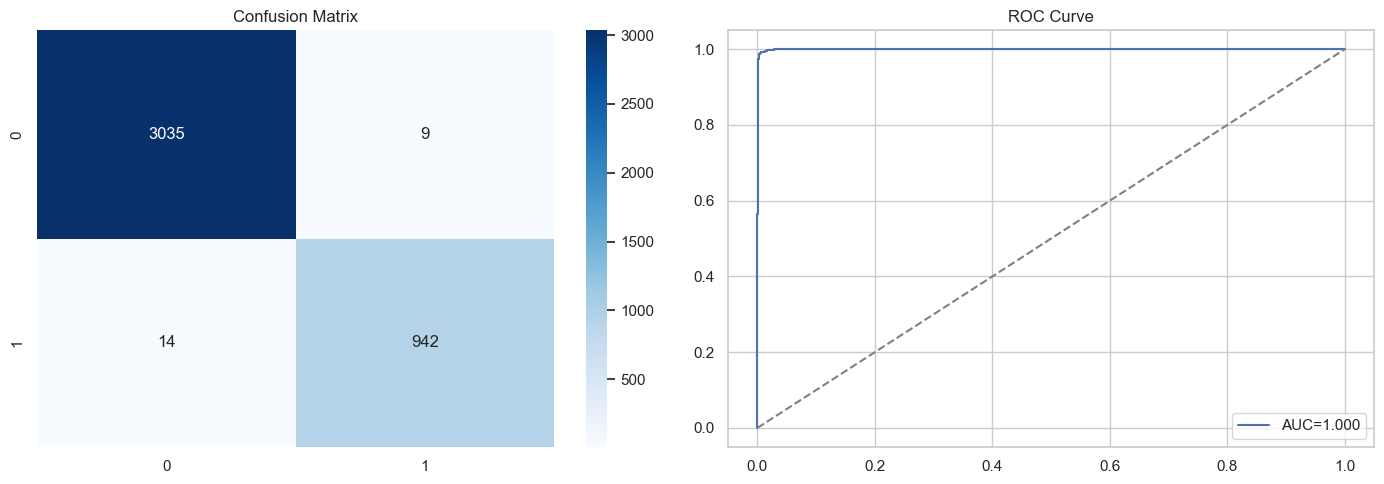

In [17]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
print('ROC-AUC:', roc_auc_score(y_test, y_prob))
print('F1:', f1_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred, zero_division=0))
print('Recall:', recall_score(y_test, y_pred, zero_division=0))
print('Business cost ($):', business_cost(y_test, y_pred))
print('Confusion [tn, fp, fn, tp]:', [tn, fp, fn, tp])
print(classification_report(y_test, y_pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, y_prob):.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

Best threshold: 0.695
Min test business cost ($): 400,000


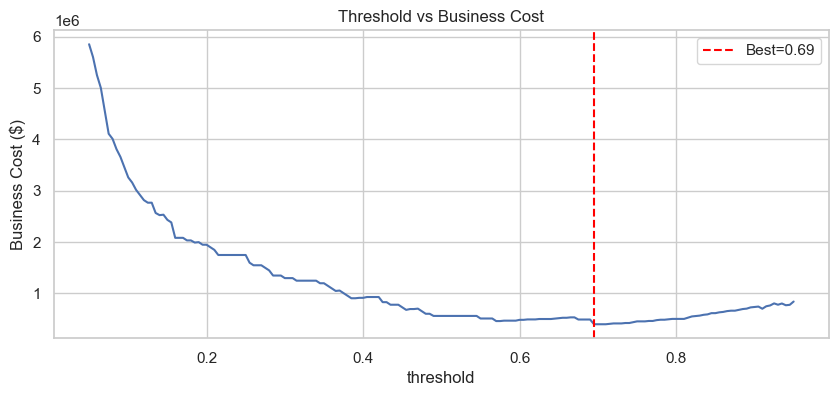

In [18]:
thresholds = np.linspace(0.05, 0.95, 181)
costs = []
for t in thresholds:
    p = (y_prob >= t).astype(int)
    costs.append(business_cost(y_test, p))

thr_df = pd.DataFrame({'threshold': thresholds, 'cost': costs})
best_idx = thr_df['cost'].idxmin()
best_t = float(thr_df.loc[best_idx, 'threshold'])
best_cost = float(thr_df.loc[best_idx, 'cost'])

print('Best threshold:', round(best_t, 3))
print('Min test business cost ($):', format(best_cost, ',.0f'))

plt.figure(figsize=(10, 4))
sns.lineplot(data=thr_df, x='threshold', y='cost')
plt.axvline(best_t, color='red', linestyle='--', label=f'Best={best_t:.2f}')
plt.title('Threshold vs Business Cost')
plt.ylabel('Business Cost ($)')
plt.legend()
plt.show()

Estimated savings vs best simple baseline ($): 7,248,000


,policy,business_cost
1,Model @ business-optimal threshold (0.69),400000
0,Model @ default threshold (0.50),562000
3,Baseline: Always deny,7648000
2,Baseline: Always approve,152200000


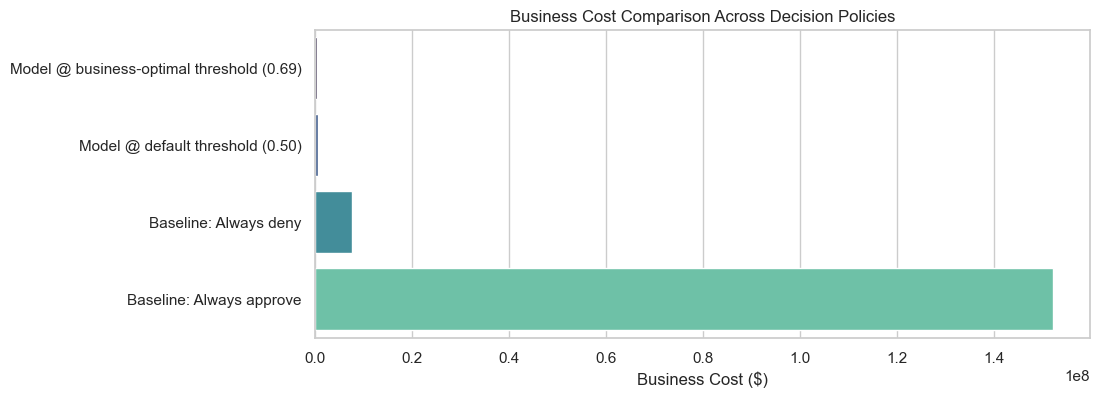

In [19]:
# Dollar-impact comparison against simple policy baselines
always_approve = np.ones_like(y_test)
always_deny = np.zeros_like(y_test)

cost_model_default_threshold = business_cost(y_test, y_pred)
cost_model_best_threshold = business_cost(y_test, (y_prob >= best_t).astype(int))
cost_always_approve = business_cost(y_test, always_approve)
cost_always_deny = business_cost(y_test, always_deny)

comparison_df = pd.DataFrame({
    'policy': [
        'Model @ default threshold (0.50)',
        f'Model @ business-optimal threshold ({best_t:.2f})',
        'Baseline: Always approve',
        'Baseline: Always deny'
    ],
    'business_cost': [
        cost_model_default_threshold,
        cost_model_best_threshold,
        cost_always_approve,
        cost_always_deny
    ]
}).sort_values('business_cost')

best_baseline_cost = min(cost_always_approve, cost_always_deny)
savings_vs_baseline = best_baseline_cost - cost_model_best_threshold

print('Estimated savings vs best simple baseline ($):', format(savings_vs_baseline, ',.0f'))
display(comparison_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=comparison_df, x='business_cost', y='policy', palette='mako')
plt.title('Business Cost Comparison Across Decision Policies')
plt.xlabel('Business Cost ($)')
plt.ylabel('')
plt.show()

In [20]:
test_eval = X_test.copy()
test_eval['actual'] = y_test.values
test_eval['pred'] = (y_prob >= best_t).astype(int)

def segment_report(frame, segment_col):
    rows = []
    for value, grp in frame.groupby(segment_col):
        if grp['actual'].nunique() < 2:
            continue
        rows.append({
            segment_col: value,
            'n': len(grp),
            'actual_approval_rate': grp['actual'].mean(),
            'pred_approval_rate': grp['pred'].mean(),
            'f1': f1_score(grp['actual'], grp['pred']),
            'precision': precision_score(grp['actual'], grp['pred'], zero_division=0),
            'recall': recall_score(grp['actual'], grp['pred'], zero_division=0),
            'business_cost': business_cost(grp['actual'], grp['pred'])
        })
    return pd.DataFrame(rows).sort_values('business_cost')

display(segment_report(test_eval, 'EmploymentStatus'))
display(segment_report(test_eval, 'EducationLevel'))

,EmploymentStatus,n,actual_approval_rate,pred_approval_rate,f1,precision,recall,business_cost
2,Unemployed,287,0.174216,0.167247,0.979592,1.000000,0.960000,16000
1,Self-Employed,311,0.263666,0.241158,0.955414,1.000000,0.914634,56000
0,Employed,3402,0.242210,0.238683,0.987775,0.995074,0.980583,328000


,EducationLevel,n,actual_approval_rate,pred_approval_rate,f1,precision,recall,business_cost
2,Doctorate,156,0.442308,0.429487,0.985294,1.000000,0.971014,16000
0,Associate,782,0.207161,0.199488,0.981132,1.000000,0.962963,48000
4,Master,620,0.377419,0.366129,0.984816,1.000000,0.970085,56000
3,High School,1086,0.152855,0.151013,0.981818,0.987805,0.975904,132000
1,Bachelor,1163,0.279450,0.276010,0.987616,0.993769,0.981538,148000


,feature,importance
27,num__RiskScore,0.783440
26,num__TotalDebtToIncomeRatio,0.123726
11,num__DebtToIncomeRatio,0.031219
19,num__MonthlyIncome,0.018771
1,num__AnnualIncome,0.007879
24,num__InterestRate,0.007334
2,num__CreditScore,0.003442
4,num__LoanAmount,0.003135
44,cat__BankruptcyHistory_No,0.002839
45,cat__BankruptcyHistory_Yes,0.002718


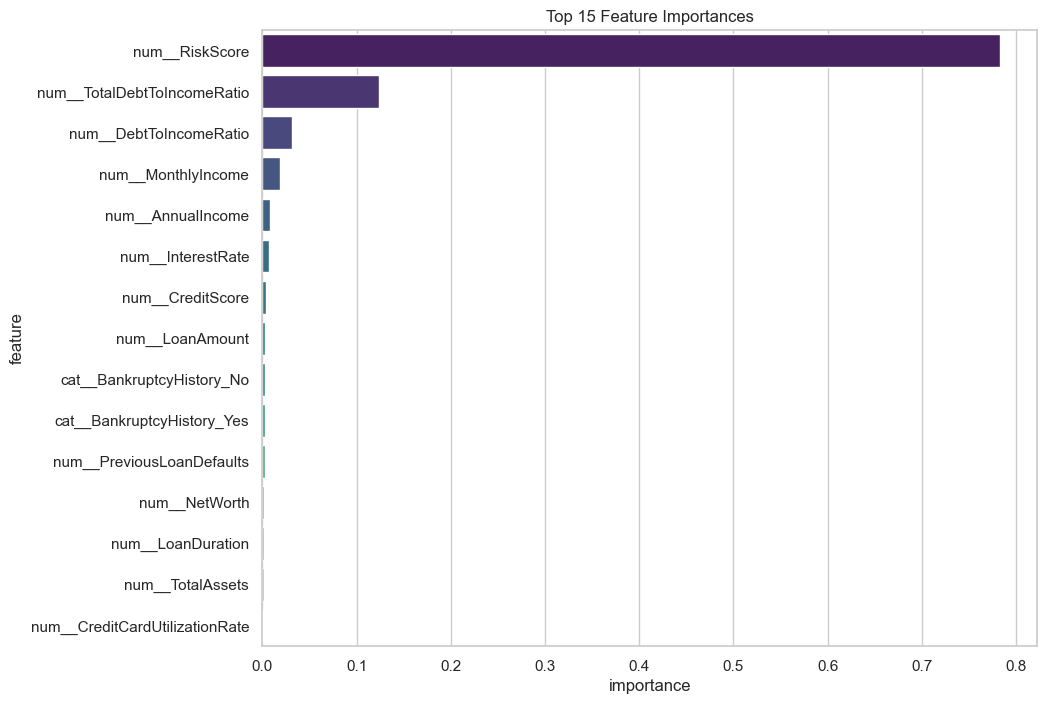

In [21]:
pre = best_model.named_steps['preprocessor']
model = best_model.named_steps['model']
feat_names = pre.get_feature_names_out()
imp_df = pd.DataFrame({'feature': feat_names, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
display(imp_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances')
plt.show()

## Limitations, Bias Checks, and Implementation Notes
- This dataset is synthetic-like and may not fully represent live applicant behavior or macroeconomic shifts.
- Group metrics should be monitored over time (for example by employment and education segments) to detect drift or disparate error rates.
- A human-in-the-loop rollout is recommended for initial deployment, with regular threshold recalibration based on current portfolio performance.
- Future improvements: probability calibration, reject-inference methods, and policy-based fairness constraints.

## Conclusion
- The final pipeline uses robust preprocessing + tuned random forest + threshold optimization.
- Business-cost-aware tuning directly aligns model decisions with financial outcomes.
- Segment-level checks support governance and fairness monitoring.
- Recommended deployment is human-in-the-loop with monthly drift and threshold recalibration.